In [183]:
from pandas.core import col
from scipy import stats
import pandas as pd
from scipy.ndimage import measurements


def mere(x:pd.Series)->dict:
    x=pd.to_numeric(x,errors="coerce").dropna().astype(float)
    if x.empty:
        return None
    positive = x[x>0]

    summary = stats.describe(x)


    q3=x.quantile(q=0.75)
    q1=x.quantile(q=0.25)

    strana = None
    asimetrija = stats.variation(x)

    if asimetrija>0:
        strana="desno"
    else:
        strana="levo"

    return{
        "n":len(x),
        "aritmeticka_sredina":x.mean(),
        "geometrijska_sredina":stats.gmean(x),
        "harmonijska_sredina":stats.hmean(x),
        "10_perc_trimovana":stats.trim_mean(x,proportiontocut=0.1),
        "raspon":x.describe().loc['max']-x.describe().loc['min'],
        "varijansa_uzorka":x.var(),
        "std_devijacija":x.std(),
        "IQR":q3-q1,
        "koeficijent_varijacije_perc":asimetrija,
        "asimetrija":stats.skew(x),
        "spljostenost":stats.kurtosis(x,bias=False),
        "q1":q1,
        "q3":q3,
        "p95":x.quantile(0.95),
        "mod":x.mode().iloc[0],
        "medijana":x.median(),
        "strana_asimetrije":strana
    }

In [184]:
df = pd.read_csv("korisnici_clean.csv",
                 parse_dates=["datum_aktivacije"])
for cat in ["region","pol", "tip_paketa", "kanal_prodaje", "churn"]:
    df[cat]=df[cat].astype("category")
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1191 entries, 0 to 1190
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id_korisnika               1191 non-null   str           
 1   region                     1191 non-null   category      
 2   pol                        1191 non-null   category      
 3   godine                     1191 non-null   int64         
 4   tip_paketa                 1191 non-null   category      
 5   staz_meseci                1191 non-null   float64       
 6   mesecni_racun_rsd          1191 non-null   float64       
 7   potrosnja_gb               1191 non-null   float64       
 8   minuti_poziva              1191 non-null   float64       
 9   broj_sms                   1191 non-null   float64       
 10  broj_reklamacija           1191 non-null   int64         
 11  kanal_prodaje              1191 non-null   category      
 12  datum_aktivacije 

## Univarijantna analiza

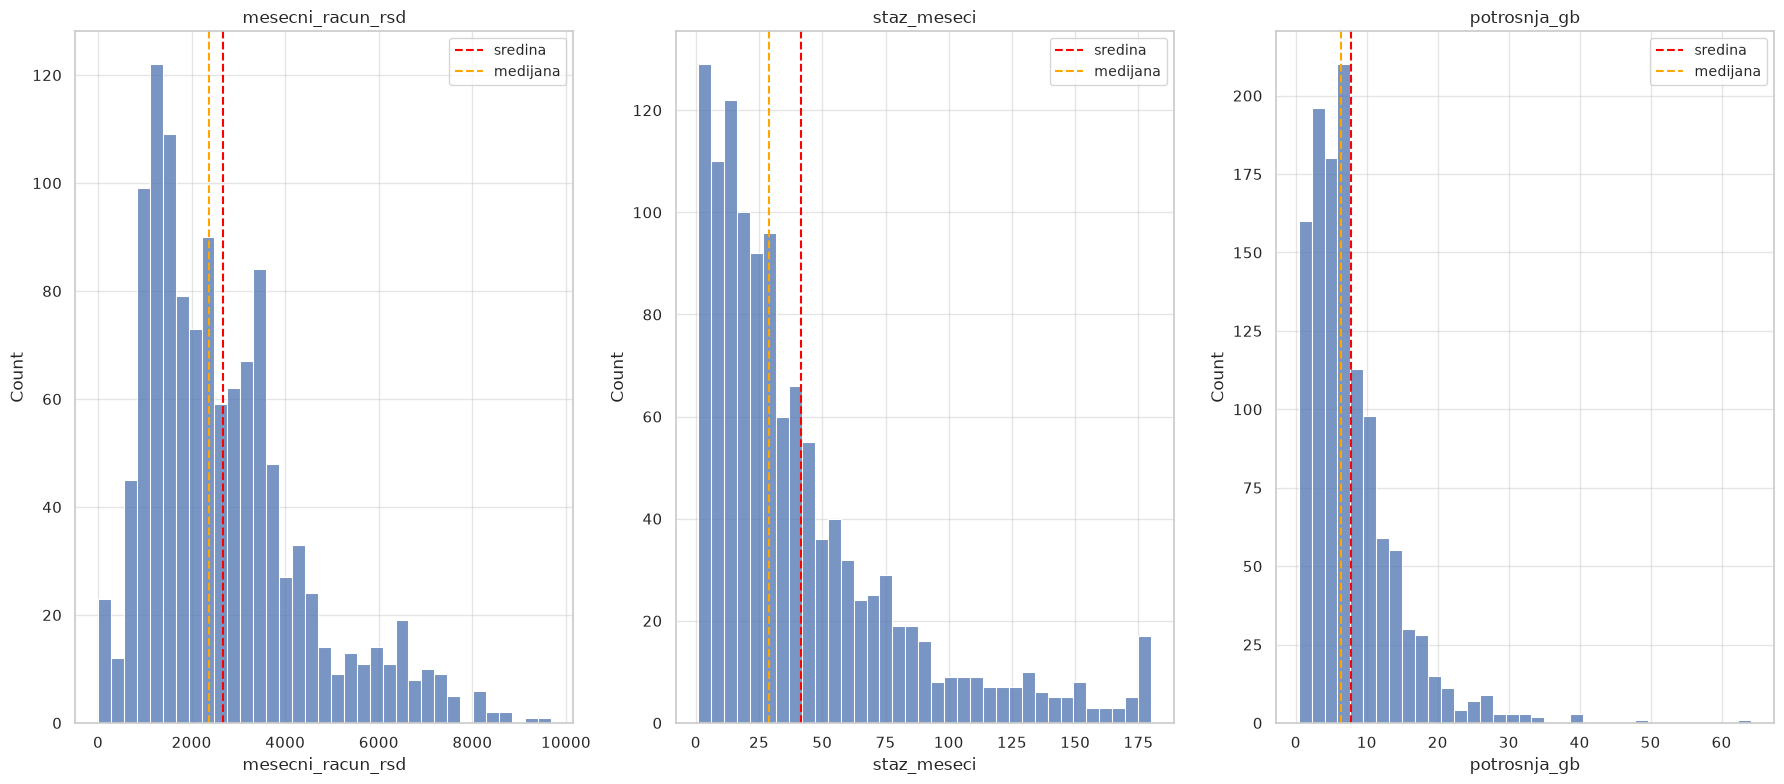

In [185]:
# Boxplot i histogram za numericke
import matplotlib.pyplot as plt, seaborn as sb
sb.set_theme(style="whitegrid")
numeric=["mesecni_racun_rsd","staz_meseci","potrosnja_gb"]

sb.set_theme(style="whitegrid")

fig,ax=plt.subplots(1,3,figsize=(18,8))

for a, col in zip(ax.flat,numeric):
    sb.histplot(df[col].dropna(),ax=a,bins=35)
    a.axvline(x=df[col].mean(),linestyle="--",label="sredina",color="red")
    a.axvline(x=df[col].median(),linestyle="--",label="medijana",color="orange")
    a.set_title(col)
    a.legend(loc="upper right",fontsize="small")
plt.tight_layout()


In [186]:
for col in numeric:
    results=mere(df[col])
    print(f"{col}:\t{results["aritmeticka_sredina"]}, {results["medijana"]}, {results["asimetrija"]} {(results["strana_asimetrije"])}")

mesecni_racun_rsd:	2673.323679261125, 2361.0, 1.1375165932650422 desno
staz_meseci:	41.48110831234257, 29.0, 1.6179713442622141 desno
potrosnja_gb:	7.743324937027707, 6.3, 2.306725446470146 desno


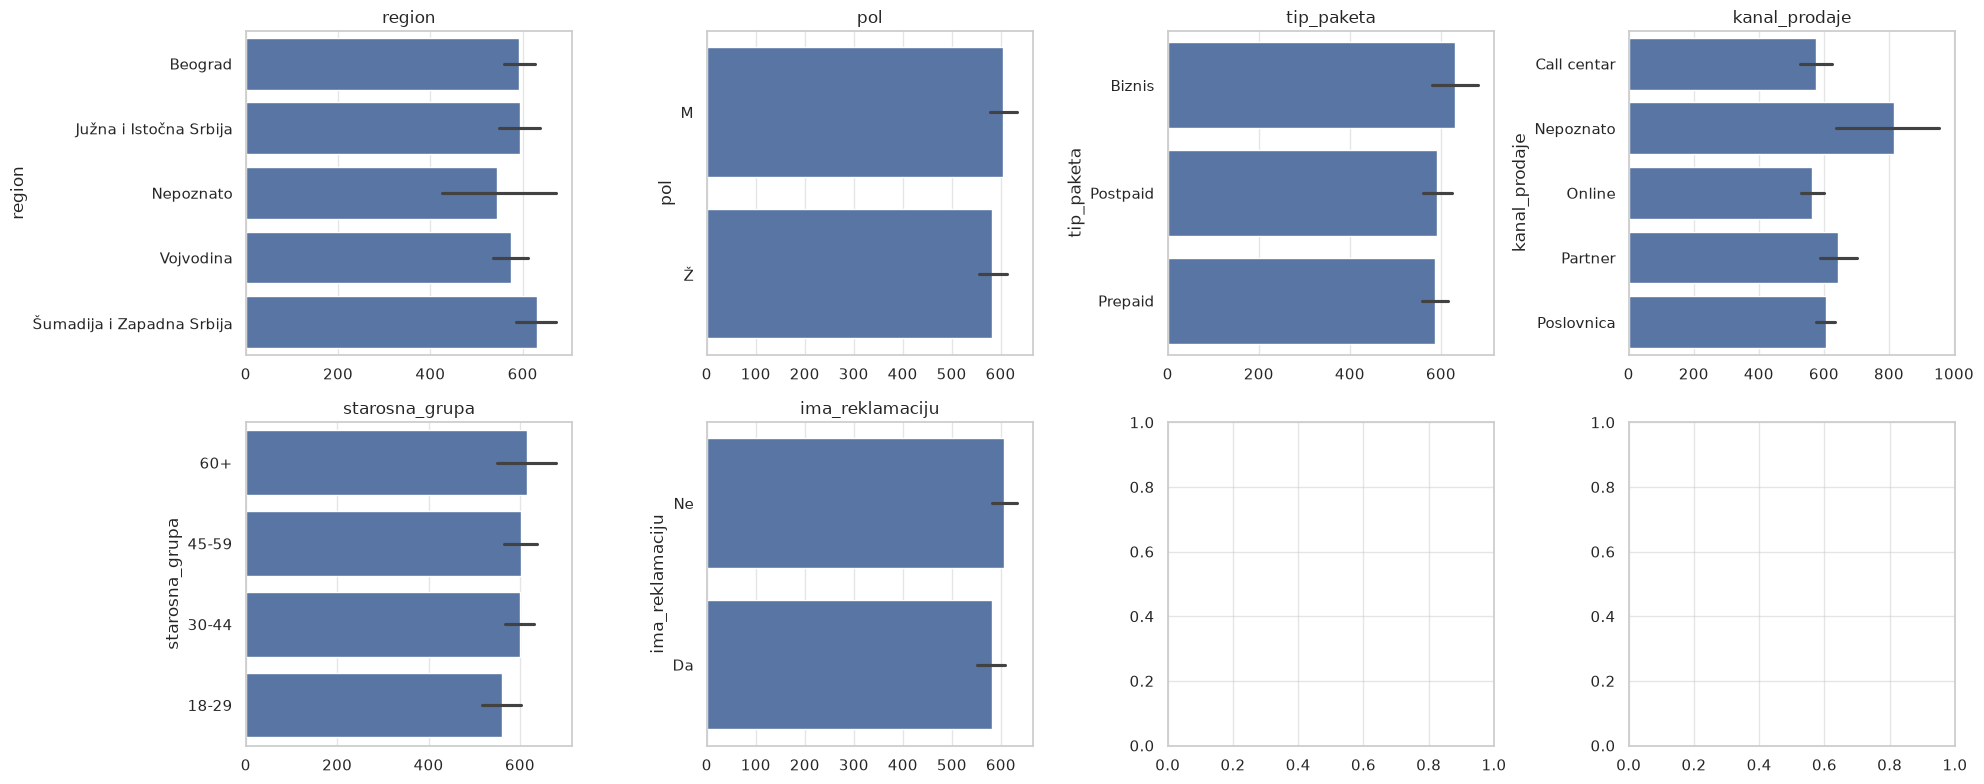

In [187]:
categories = ["region","pol","tip_paketa","kanal_prodaje","starosna_grupa","ima_reklamaciju"]

fig,ax=plt.subplots(2,4,figsize=(20,8))

for a, col in zip(ax.flat,categories):
    sb.barplot(df[col],ax=a,legend=True)
    a.set_title(col)

plt.tight_layout()

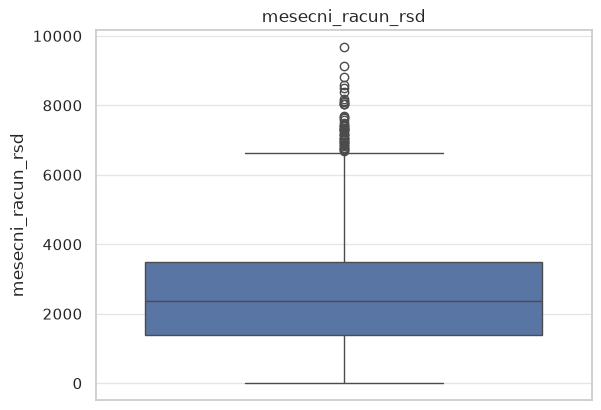

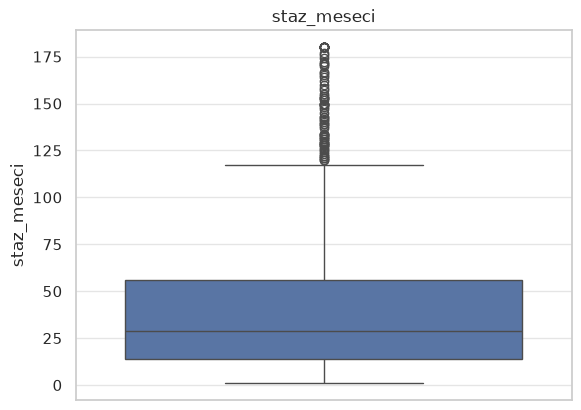

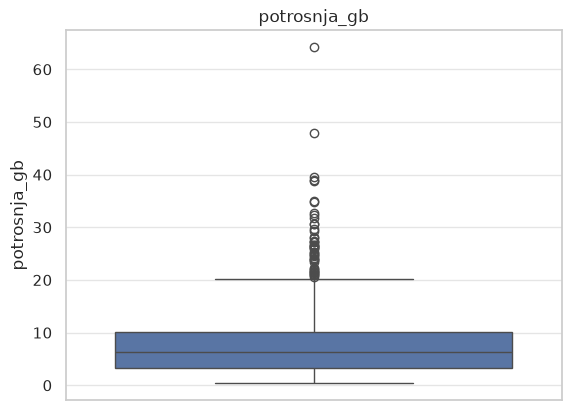

In [188]:

for col in numeric:
    plt.figure()
    plt.title(col)
    sb.boxplot(data=df[col])

    plt.show()


In [189]:
results_clean=[]

for col in numeric:
    results_clean.append(mere(df[col]))

categories = ["region","pol","tip_paketa","kanal_prodaje","starosna_grupa"]

## Churn po segmentima

 Ukupno:	22.334172963895885%, n=1191
-----
Najvece stope:

pol Ž 23.06
tip_paketa Prepaid 29.56
kanal_prodaje Partner 24.46
starosna_grupa 30-44 24.95
staz_grupa go 1 god 32.57


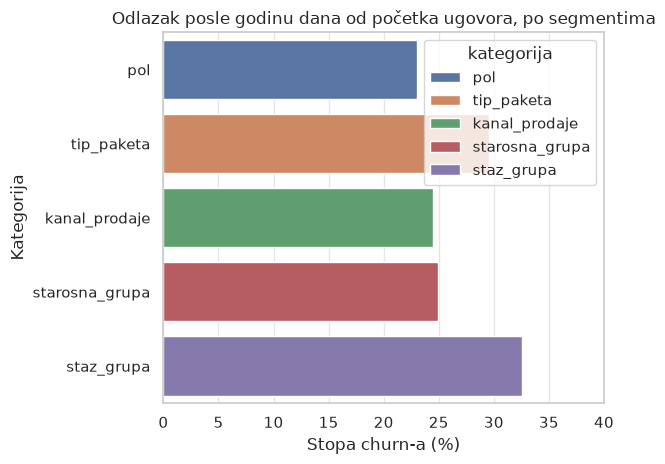

In [190]:
cond = df["churn"]=="Da"
print(f" Ukupno:\t{df.loc[cond,"churn"].value_counts()["Da"]/len(df["churn"])*100}%, n={len(df)}")


group_cats=["pol","tip_paketa","kanal_prodaje","starosna_grupa","staz_grupa"] #ubaci i "region"
group_report=[]

for cat in group_cats:
    percent = df.groupby(cat,observed=True)["churn_flag"].agg(n="count",stopa="mean").reset_index()
    percent['stopa']*=100
    group_report.append(percent)

print("-----\nNajvece stope:\n")

najvece_stope = []

for elem in group_report:
    cond = elem["n"]>100
    valid = elem.loc[cond] # same vrednosti
    index = valid["stopa"].idxmax() # index-i po kojima gledam

    print(elem.columns[0],valid.loc[index,elem.columns[0]],round(valid.loc[index,"stopa"],2))

    najvece_stope.append({
        "kategorija": elem.columns[0],
        "grupa": valid.loc[index,elem.columns[0]],
        "stopa": round(valid.loc[index,"stopa"],2)
    })

churn_grafik = pd.DataFrame(najvece_stope)

plt.figure()

sb.barplot(
    data=churn_grafik,
    x=churn_grafik.columns[2],
    y=churn_grafik.columns[0],
    hue=churn_grafik.columns[0],
    legend=True

)
plt.xlabel("Stopa churn-a (%)")
plt.ylabel("Kategorija")
plt.xlim(0, 40)
plt.title("Odlazak posle godinu dana od početka ugovora, po segmentima")
plt.tight_layout()
plt.savefig("grafikoni/churn_po_seg.png", dpi=130)
plt.show()

In [191]:
# Poredjenje medijana
numeric=["mesecni_racun_rsd","staz_meseci","potrosnja_gb","godine","broj_reklamacija","ocena_zadovoljstva"]

diff=df.groupby("churn")[["mesecni_racun_rsd","staz_meseci","potrosnja_gb","godine","broj_reklamacija","ocena_zadovoljstva"]].median()
display(diff)

,mesecni_racun_rsd,staz_meseci,potrosnja_gb,godine,broj_reklamacija,ocena_zadovoljstva
churn,,,,,,
Da,2118.0,21.0,6.3,41.0,1.0,3.0
Ne,2410.0,31.0,6.3,43.0,0.0,4.0


Ocito je da `ocena_zadovoljstva` izmedju `3` i `4` je prelomni trenutak.

   ocena_zadovoljstva      n      stopa
0                 1.0   1700  64.705882
1                 2.0  12700  53.543307
2                 3.0  33200  28.614458
3                 4.0  40000  12.250000
4                 5.0  21900  11.872146


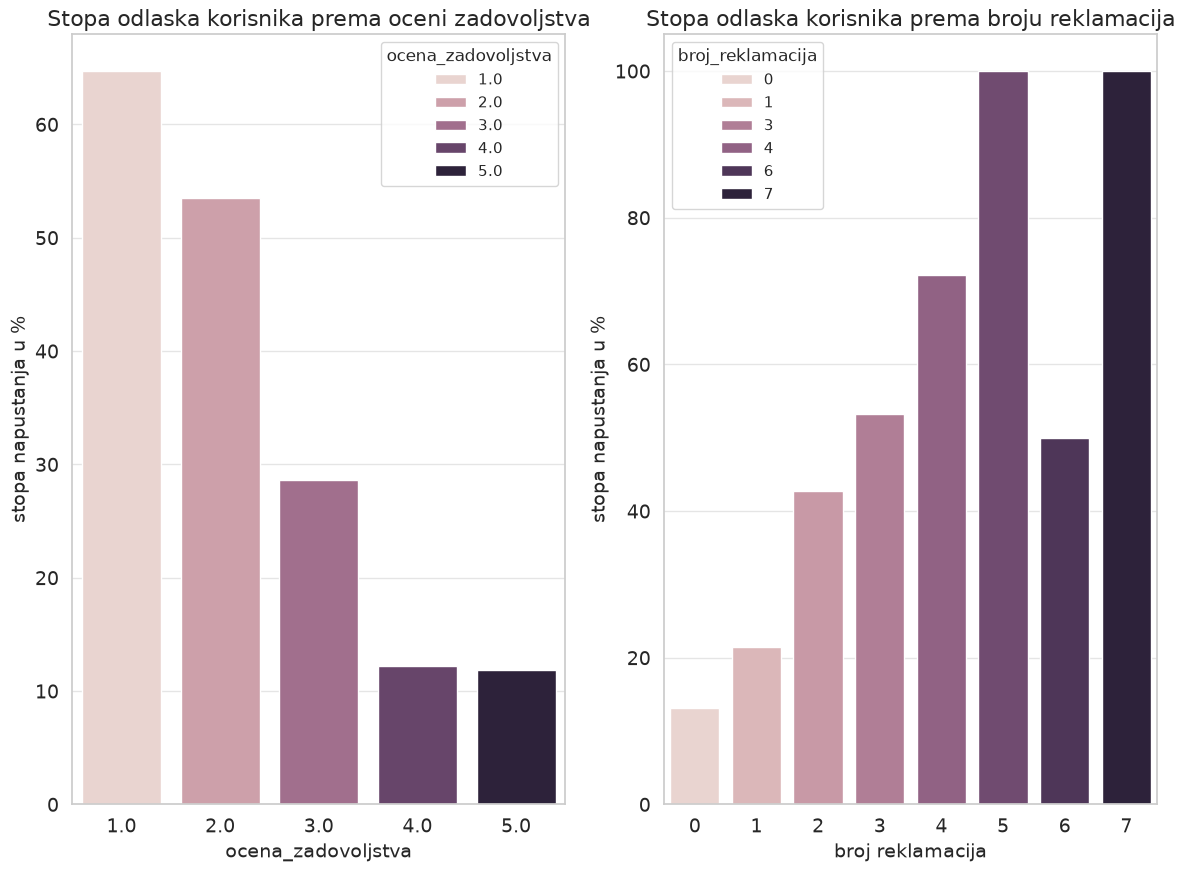

In [192]:
#group_cats=["tip_paketa","staz_grupa"] #ubaci i "region"

plan_type = pd.DataFrame((df.groupby("ocena_zadovoljstva",observed=True)["churn_flag"].agg(n="count",stopa="mean")*100).reset_index())
years = pd.DataFrame((df.groupby("broj_reklamacija",observed=True)["churn_flag"].agg(n="count",stopa="mean")*100).reset_index())
print(plan_type)

plt.figure(figsize=(14,10))
plt.subplot(1,2,1)
sb.barplot(data=plan_type,x="ocena_zadovoljstva",y="stopa",hue="ocena_zadovoljstva",legend=True)
plt.ylabel("stopa napustanja u %",fontsize=14)
plt.xlabel("ocena_zadovoljstva",fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("Stopa odlaska korisnika prema oceni zadovoljstva",fontsize=16)
plt.subplot(1,2,2)
sb.barplot(data=years,x="broj_reklamacija",y="stopa",hue="broj_reklamacija",legend=True)
plt.ylabel("stopa napustanja u %",fontsize=14)
plt.title("Stopa odlaska korisnika prema broju reklamacija",fontsize=16)
plt.xlabel("broj reklamacija",fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig("grafikoni/churn_po_rekl_ocena.png",dpi=130)
plt.show()

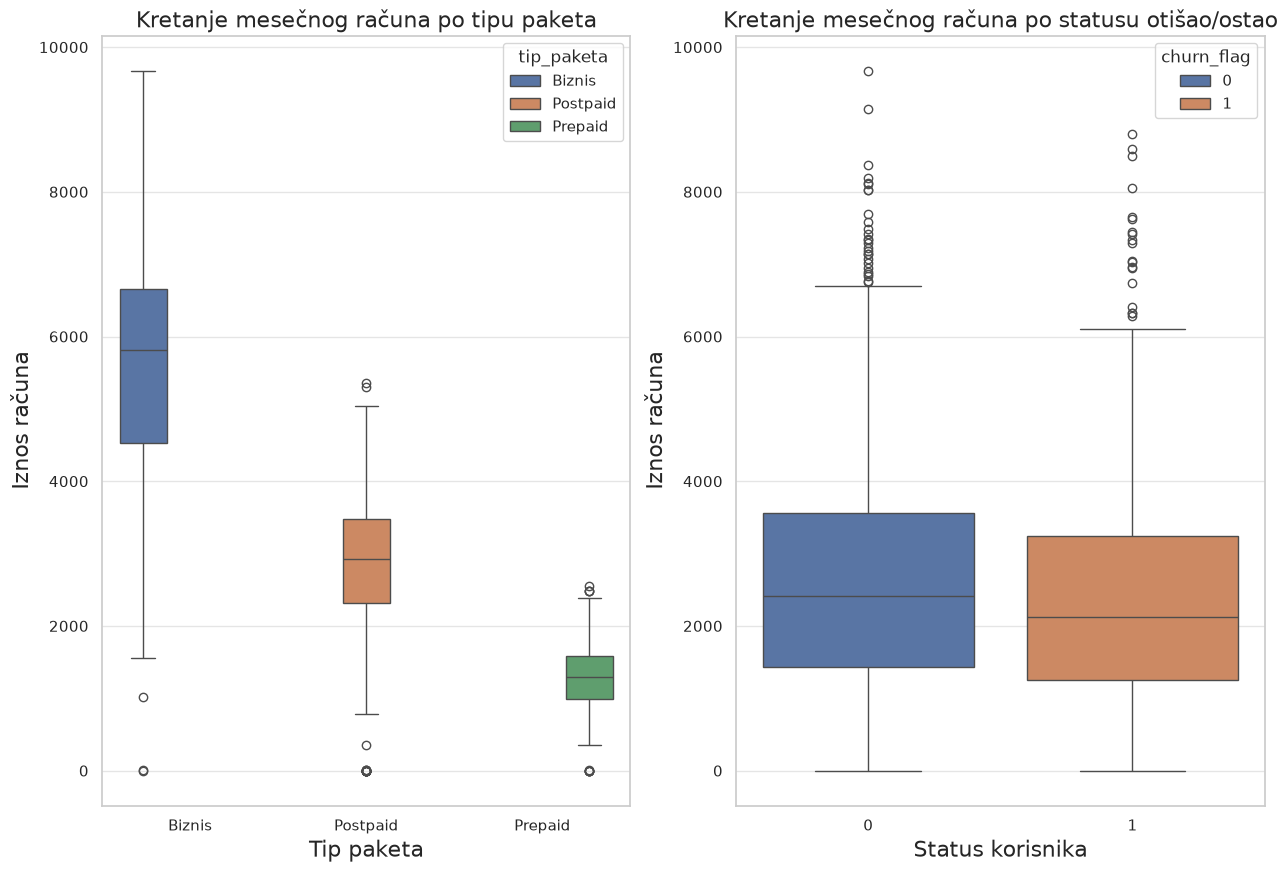

In [193]:
plt.figure(figsize=(15,10))

plt.subplot(1,2,1)
sb.boxplot(data=df,x="tip_paketa",y="mesecni_racun_rsd",hue="tip_paketa", legend=True)

plt.title("Kretanje mesečnog računa po tipu paketa",fontsize=16)
plt.xlabel("Tip paketa",fontsize=16)
plt.ylabel("Iznos računa",fontsize=16)

plt.subplot(1,2,2)
sb.boxplot(data=df,x="churn_flag",y="mesecni_racun_rsd",hue="churn_flag",legend=True)
plt.title("Kretanje mesečnog računa po statusu otišao/ostao",fontsize=16)
plt.xlabel("Status korisnika",fontsize=16)
plt.ylabel("Iznos računa",fontsize=16)

plt.savefig("./grafikoni/boxplot_racun.png",dpi=130)
plt.show()






## Korelacije

Оčito da ću morati da koristim `Spearman`-ovu korelaciju budući da imamo masu promenljivih koje su nenormalno raspoređene. Utvrđeno je u `01_profilisanje.ipynb`, a uz put smo i računali asimetriju koja je dosta daleko od nule.

ocena_zadovoljstva   -0.31
staz_meseci          -0.14
mesecni_racun_rsd    -0.09
godine               -0.02
potrosnja_gb         -0.00
broj_reklamacija      0.30
Name: churn_flag, dtype: float64


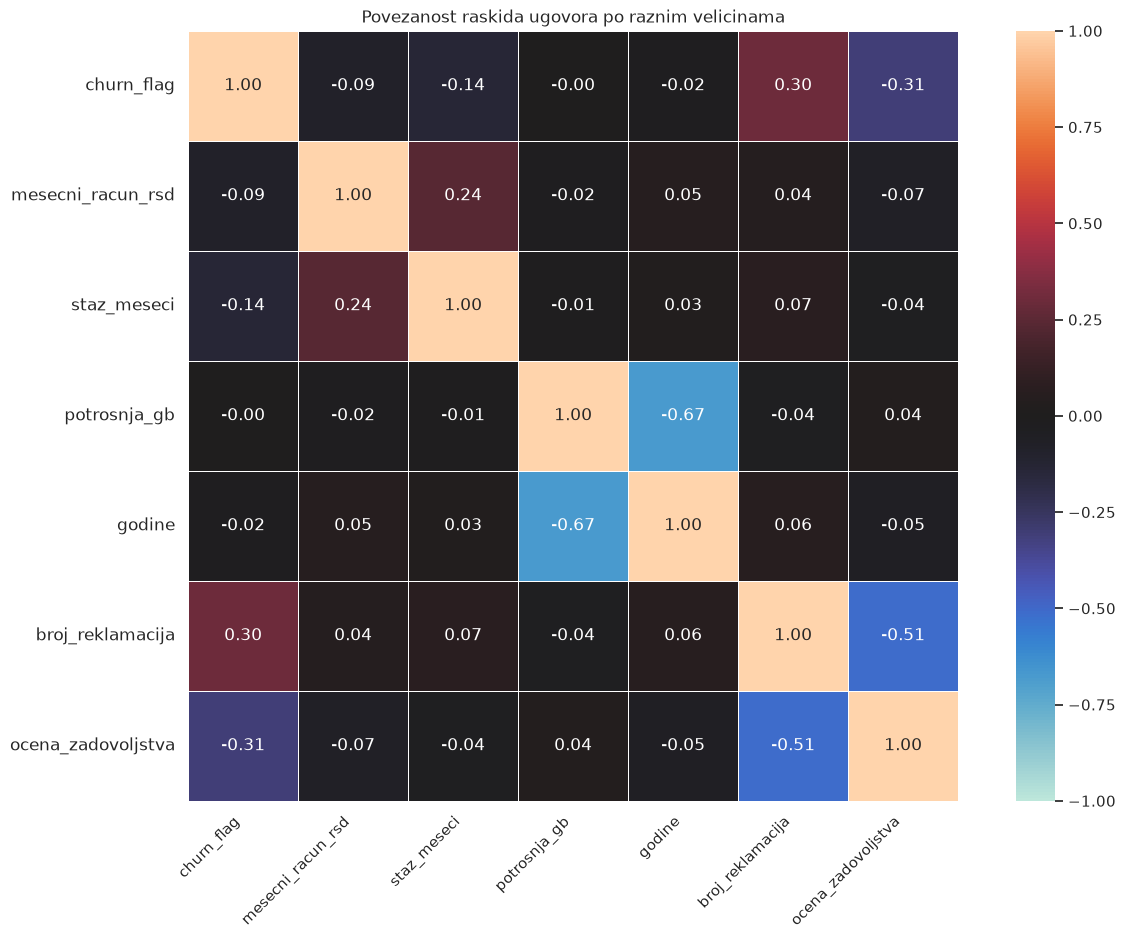

In [194]:

numeric=["mesecni_racun_rsd","staz_meseci","potrosnja_gb","godine","broj_reklamacija","ocena_zadovoljstva"]
corr = df[["churn_flag"]+numeric].corr(method="spearman")

print(round(corr["churn_flag"].drop("churn_flag"),2).sort_values())

plt.figure(figsize=(15,10))
plt.title("Povezanost raskida ugovora po raznim velicinama")

sb.heatmap(data=corr,fmt=".2f",annot=True,center=0,vmin=-1,vmax=1,square=True,linewidths=0.5)

plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=12)
plt.savefig("grafikoni/korelaciona_mat.png", dpi=130)

plt.show()



In [195]:
for cat in ["ima_reklamaciju","ima_potrosnje","staz_grupa","starosna_grupa"]:
    df[cat]=df[cat].astype("category")
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1191 entries, 0 to 1190
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id_korisnika               1191 non-null   str           
 1   region                     1191 non-null   category      
 2   pol                        1191 non-null   category      
 3   godine                     1191 non-null   int64         
 4   tip_paketa                 1191 non-null   category      
 5   staz_meseci                1191 non-null   float64       
 6   mesecni_racun_rsd          1191 non-null   float64       
 7   potrosnja_gb               1191 non-null   float64       
 8   minuti_poziva              1191 non-null   float64       
 9   broj_sms                   1191 non-null   float64       
 10  broj_reklamacija           1191 non-null   int64         
 11  kanal_prodaje              1191 non-null   category      
 12  datum_aktivacije 

None

## Testiranje hipoteza

1) Da li se neki paketi preferiraju u nekom kanalu prodaje ?

In [196]:
from scipy.stats import chi2_contingency

cont_tb = pd.crosstab(df["tip_paketa"],df["kanal_prodaje"],normalize="index") #index->raspodela po kanalima

chi2,p,dof,expected = chi2_contingency(cont_tb)

print(f"{p}, n={len(df)}")


0.999999998992705, n=1191


Očito je da $0.99>>0.05$ tj možemo da kažemo da NE postoji osnovana sumnja u povezanost izbora paketa prema kanalu prodaje.

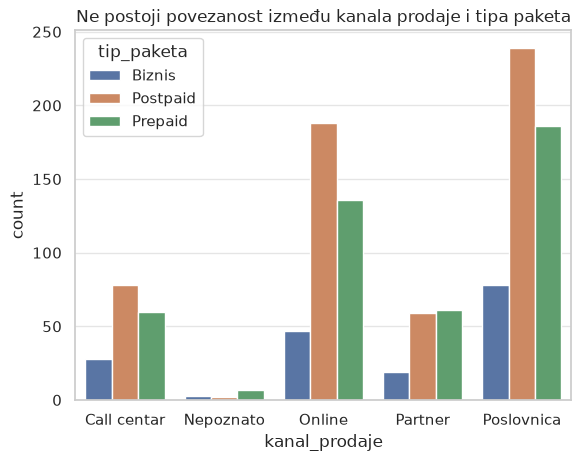

In [197]:
# Countplot
plt.figure()

sb.countplot(data=df,x="kanal_prodaje",hue="tip_paketa")
plt.title("Ne postoji povezanost između kanala prodaje i tipa paketa")
plt.savefig("grafikoni/paket_kanal.png",dpi=130)
plt.show()

2) Da li na odlazak pre godinu dana ima uticaj kanal prodaje kojim je ugovoren paket ? (`churn` naspram `kanal_prodaje`)

In [198]:
cont_tb = pd.crosstab(df["churn_flag"],df["kanal_prodaje"],normalize=True)

chi2,p,dof,expected = chi2_contingency(cont_tb)

print(f"{chi2:.3f}, {p:.3f}, {dof:.3f}")


0.002, 1.000, 4.000


Ne postoji osnovana sumnja da je kanal prodaje povezan sa ranim gubitkom korisnika.

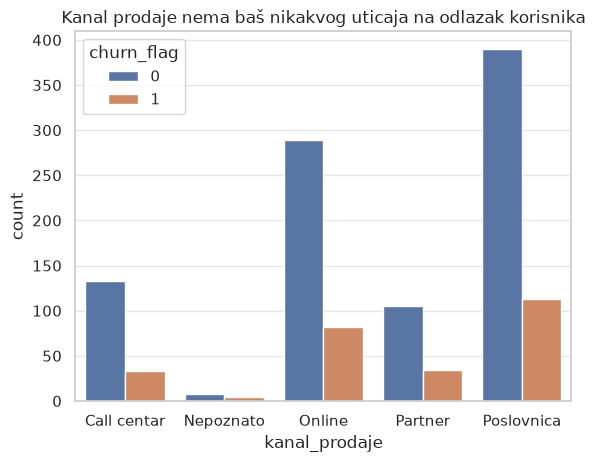

In [199]:
# Countplot
plt.figure()

sb.countplot(data=df,x="kanal_prodaje",hue="churn_flag")
plt.title("Kanal prodaje nema baš nikakvog uticaja na odlazak korisnika")
plt.savefig("grafikoni/kanal_tip.png",dpi=130)

plt.show()

3) Da li više melju preko telefona muškarci i žene ? Poredimo po starosnim grupama (malopre utvrđenim)

In [200]:
from scipy.stats import mannwhitneyu

frame = df.loc[df["tip_paketa"]!="Biznis"].copy().groupby("starosna_grupa",observed=True)

for group,df_group in frame:
    talk_men = df_group.loc[df_group["pol"]=="M","minuti_poziva"]
    talk_women = df_group.loc[df_group["pol"]=="Ž","minuti_poziva"]

    u,p = mannwhitneyu(talk_men,talk_women,alternative="two-sided") # mislimo da ima razlike u rangovima

    print(f"{group} {round(p,2)>0.05}")

18-29 True
30-44 True
45-59 True
60+ True


Vidimo da broj minuta priče preko telefona je manje/više isti. Pri tome, `Biznis` korisnici su isključeni iz analize, jer ne možemo znati nužno da li se telefon vodi na radnika ili na firmu.

4) Da li starosna grupa opredeljuje izbor paketa ?

In [201]:
cont_tb = pd.crosstab(df["starosna_grupa"],df["tip_paketa"],normalize=True)

chi2,p,dof,expected = chi2_contingency(cont_tb)

print(f"{chi2:.3f}, {p:.3f}, {dof:.3f}")

0.006, 1.000, 6.000


Ne postoji razlog za sumnju za ovakvu vrstu opredeljenosti.

5) Pregled minutaže po starosnim grupama i utvrđivanje povezanosti

In [202]:
frame = df.groupby("starosna_grupa",observed=True)

from scipy.stats import shapiro,kruskal

for name, data in frame:
    stat,p_val = shapiro(data["minuti_poziva"])
    print(f"{name} {stat} {round(p_val,2)>0.05}")



samples = [
    data["minuti_poziva"].dropna()
    for _,data in frame
]

stat,p_val = kruskal(*samples)
print("\nStatistika:")
print(f"{round(p_val,2)}, {stat}")


18-29 0.9924483232799972 True
30-44 0.9907044147341753 False
45-59 0.9908580990151717 False
60+ 0.9738894750877839 False

Statistika:
0.11, 6.006881601156177


Kako je $0.1 >> 0.05$ nemamo razloga da sumnjamo da postoji neka pravilnost u minutaži priče među pripadnicima naših starosnih grupa

Text(0.5, 1.0, 'Ne postoji razlika u tipicnim predstavnicima starosnih grupa')

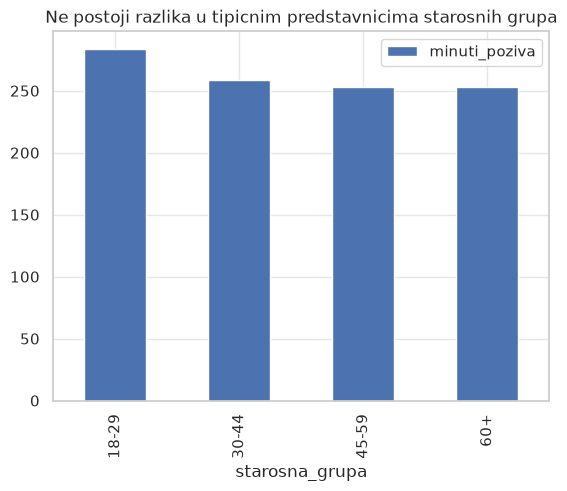

In [203]:
medians = pd.DataFrame(frame["minuti_poziva"].median())

medians.plot(kind="bar")
plt.title("Ne postoji razlika u tipicnim predstavnicima starosnih grupa")

6) Postoje li pattern-i u korišćenju interneta, priči i slanju SMS poruka u starosnim grupama ?

In [204]:
# frame vec imamo od malo pre

print("Kolona/grupa/statistika/p_val")
for name,data in frame:
    for col in ["potrosnja_gb","broj_sms"]:
        stat,p_val = shapiro(data[col])
        print(f"{col}/{name}/{stat}/{p_val>0.05}\n")

print("\nKruskall:")
for col in ["potrosnja_gb", "broj_sms","minuti_poziva"]:
    samples = []

    for name, data in frame:
        samples.append(data[col].dropna())
        print(name,len(data))

    H, p = kruskal(*samples)

    print(col, H, p, p>0.05)

Kolona/grupa/statistika/p_val
potrosnja_gb/18-29/0.8403937597246895/False

broj_sms/18-29/0.9938195607503475/True

potrosnja_gb/30-44/0.8983516906404189/False

broj_sms/30-44/0.9919417972501722/False

potrosnja_gb/45-59/0.9083734997203778/False

broj_sms/45-59/0.987474350065539/False

potrosnja_gb/60+/0.7990545221472244/False

broj_sms/60+/0.9903610304513112/True


Kruskall:
18-29 221
30-44 477
45-59 380
60+ 113
potrosnja_gb 478.49009716738937 2.187645375961544e-103 False
18-29 221
30-44 477
45-59 380
60+ 113
broj_sms 2.10539239469693 0.5508226157416134 True
18-29 221
30-44 477
45-59 380
60+ 113
minuti_poziva 6.006881601156177 0.11127589981927229 True


Nemamo dokaza da sumnjamo u razliku u koriscenju poruka i telefoniraju, ali u koriscenju interneta itekako.

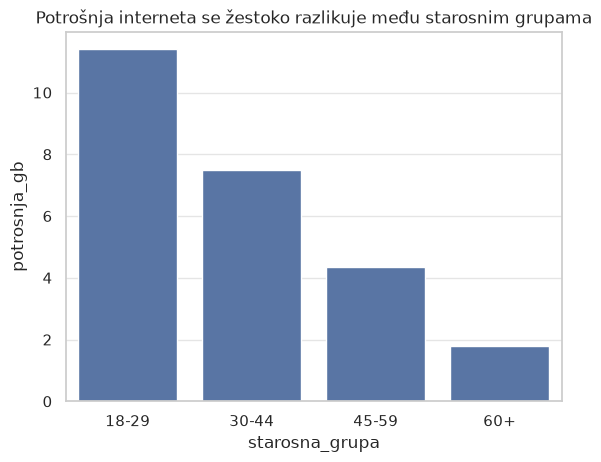

In [205]:
#print(frame["potrosnja_gb"].median())
medians = frame["potrosnja_gb"].median()
plt.figure()

plt.title("Potrošnja interneta se žestoko razlikuje među starosnim grupama")
sb.barplot(data=medians,legend=True)
plt.savefig("grafikoni/potrosnja_neta.png",dpi=130)
plt.show()


Zapažanje za mentora: Bez obzira na to što raspodela `broj_sms` nije normalna skroz (u kategoriji penzoša i "mlađarije" je jedino), medijana i prosek se skoro uopšte ne razlikuju. Verovatno da smo nastavili da snimamo saobraćaj, prilično sam siguran da bi raspodela bila normalna.

18-29


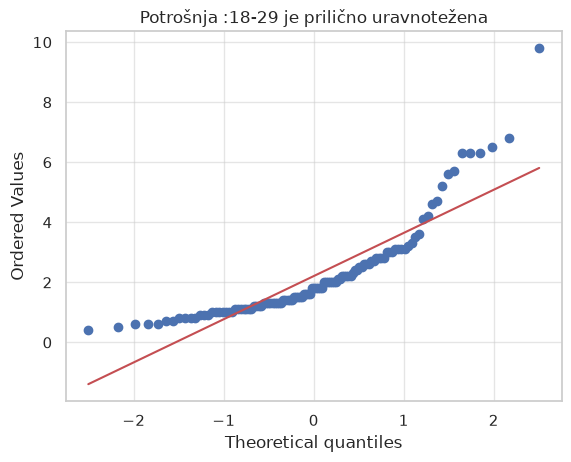

30-44


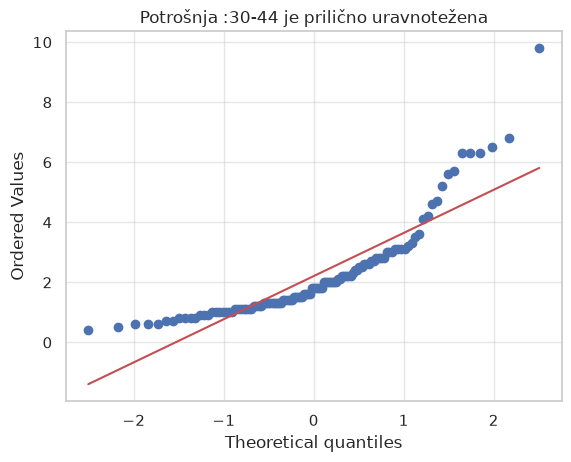

45-59


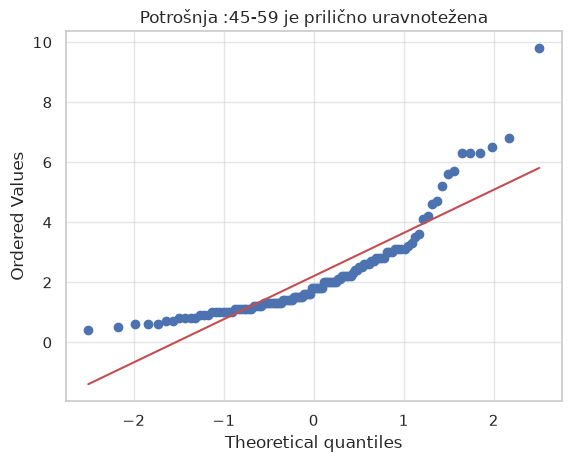

60+


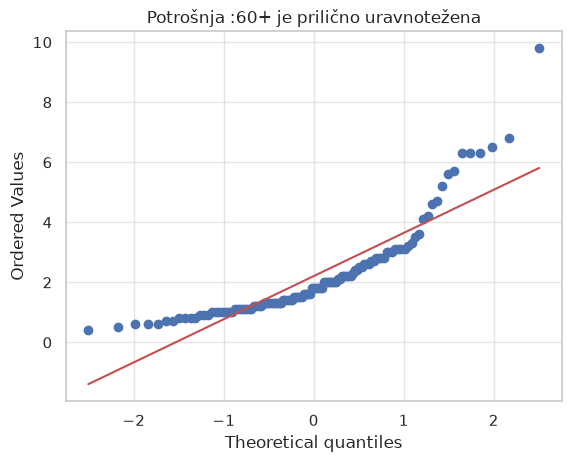

In [206]:
for name, group in frame:
    print(name)
    plt.figure()
    stats.probplot(data["potrosnja_gb"].dropna(),dist="norm",plot=plt)
    plt.title(f"Potrošnja :{name} je prilično uravnotežena")
    plt.savefig(f"grafikoni/potrosnja_{name}.png",dpi=130)
    plt.show()

## Trazeni grafici

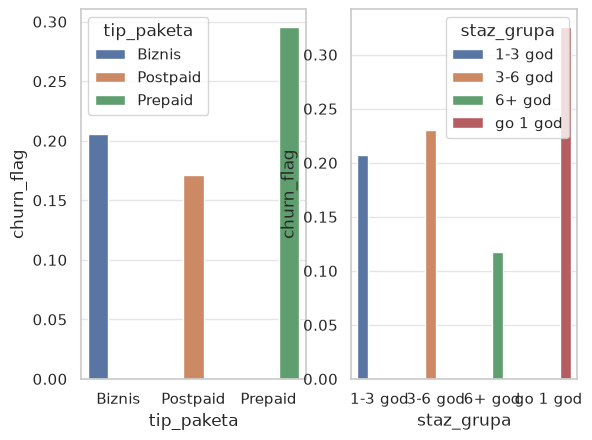

In [207]:
# Stopa churn-a po tipu paketa i po grupi staža
plan_type = df.groupby("tip_paketa",observed=True)["churn_flag"].mean().reset_index()
staz_grupa = df.groupby("staz_grupa")["churn_flag"].mean().reset_index()

plt.figure()
plt.subplot(1,2,1)

sb.barplot(data=plan_type,y="churn_flag",x="tip_paketa",hue="tip_paketa",legend=True)
plt.subplot(1,2,2)

sb.barplot(data=staz_grupa,y="churn_flag",x="staz_grupa",hue="staz_grupa",legend=True)
plt.show()

In [208]:
# Stopa churn-a po oceni zadovoljstva i po broju reklamacija
contente_degree = df.groupby("ocena_zadovoljstva",observed=True)["churn_flag"].mean().reset_index()
zalbadzije = df.groupby("broj_reklamacija")["churn_flag"].mean().reset_index()



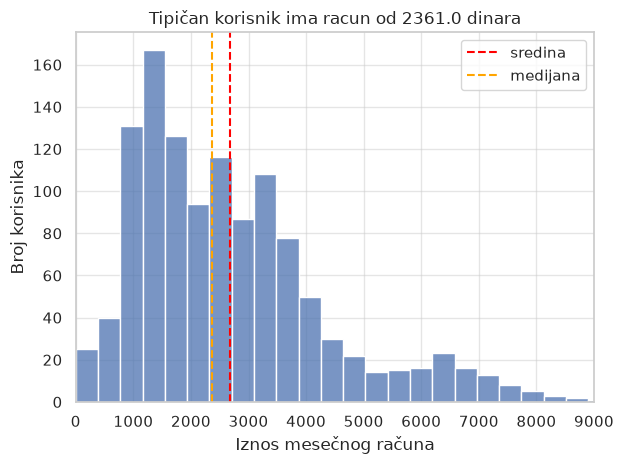

'Medijana je bliza tamo gde nam je broj korisnika najveci, nego sto je sredina'

In [209]:
# Histogram mesečnog računa sa sredinom i medijanom — ilustracija zašto medijana
plt.figure()

sb.histplot(data=df["mesecni_racun_rsd"])
plt.xlim(0,9000)
plt.axvline(x=df["mesecni_racun_rsd"].mean(),linestyle="--",label="sredina",color="red")

plt.axvline(x=df["mesecni_racun_rsd"].median(),linestyle="--",label="medijana",color="orange")
plt.title(f"Tipičan korisnik ima racun od {df["mesecni_racun_rsd"].median()} dinara")
plt.ylabel("Broj korisnika")
plt.xlabel("Iznos mesečnog računa")
plt.legend()
plt.tight_layout()
plt.savefig("grafikoni/tipican_mesecni_racun.png", dpi=130, bbox_inches="tight")
plt.show()
display("Medijana je bliza tamo gde nam je broj korisnika najveci, nego sto je sredina")


<Figure size 2000x2000 with 0 Axes>

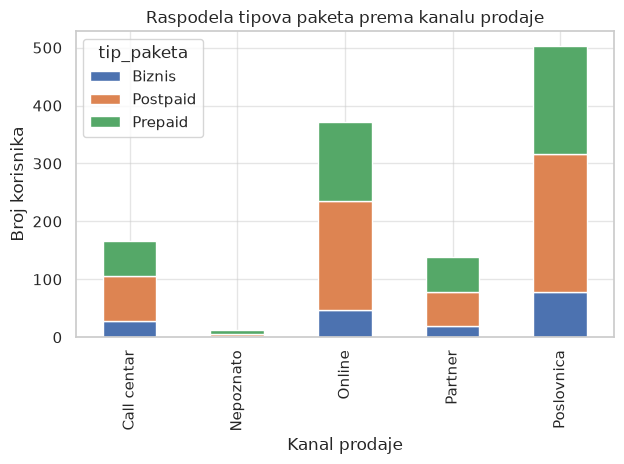

In [210]:
# Preferiranje nekog tipa paketa u odnosu na kanal prodaje

plt.figure(figsize=(20,20))
pd.crosstab(df["kanal_prodaje"], df["tip_paketa"]).plot(
    kind="bar",
    stacked=True
)

plt.xlabel("Kanal prodaje")
plt.ylabel("Broj korisnika")
plt.title("Raspodela tipova paketa prema kanalu prodaje")
plt.tight_layout()
plt.savefig("./grafikoni/paket_kanal.png",dpi=130)
plt.show()